# A custom cavity from scratch: the cone

This notebook defines a **brand-new geometry** — a straight-walled cone cavity — and runs the
full analysis stack on it. The point: a custom model that implements the small
[Cavity contract](../../extending) (`parameters`, `profile()`, `rebuild()`, `create()`) plugs
into **eigenmode, tuning and wakefield** with no changes anywhere in the framework, because a
single labelled meridian (see [geometry](../../geometry)) serves every analysis.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt

from cavsim2d import Study
from cavsim2d.utils.style import apply_style

apply_style()

## 1. Define the geometry

Three parameters (`L`, `Req`, `Ri`), a `profile()` that walks the wall labelling the metal
`PEC` and the apertures `PMC`, and a one-line `rebuild()` — that is the whole model.

In [2]:
import os
from cavsim2d.models.base import Cavity
from cavsim2d.geometry import Profile


class ConeCavity(Cavity):
    """A single-cell cavity whose wall tapers straight from the aperture up to a
    central equator and back. dims = [L, Req, Ri] in mm."""

    def __init__(self, dims, name='cone'):
        super().__init__(n_cells=1, beampipe='none', name=name)
        L, Req, Ri = dims
        self.n_cells, self.kind, self.beampipe = 1, 'cone', 'none'
        self.parameters = {'L': float(L), 'Req': float(Req), 'Ri': float(Ri)}
        self.shape = {'IC': [L, Req, Ri], 'BP': 'none'}   # tuner writes ['FREQ'] here

    def profile(self):
        try:
            L, Req, Ri = (self.parameters[k] * 1e-3 for k in ('L', 'Req', 'Ri'))
        except (KeyError, TypeError, ValueError):
            return None
        p = Profile('cone')
        p.start(-L / 2, 0.0)
        p.line_to(-L / 2, Ri, 'PMC')     # left aperture plane
        p.line_to(0.0, Req, 'PEC')       # taper up to the equator (wall)
        p.line_to(L / 2, Ri, 'PEC')      # taper down to the right aperture
        p.line_to(L / 2, 0.0, 'PMC')     # right aperture plane
        p.close('AXI')                   # close along the axis
        return p

    def create(self, n_cells=None, beampipe=None, mode=None):
        if self.projectDir:
            self.self_dir = os.path.join(self.projectDir, self.name)
            os.makedirs(os.path.join(self.self_dir, 'geometry'), exist_ok=True)
            self.uq_dir = os.path.join(self.self_dir, 'uq')
            self.geo_filepath = None       # native-only: the solver meshes profile()
            self._write_geometry_snapshot()

    def rebuild(self, parameters, beampipe=None):
        return ConeCavity([parameters['L'], parameters['Req'], parameters['Ri']],
                          name=self.name)

## 2. Build and view it

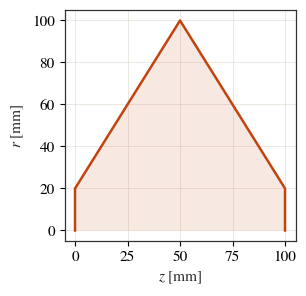

<Axes: xlabel='$z$ [mm]', ylabel='$r$ [mm]'>

In [3]:
cav = ConeCavity([100, 100, 20])          # L = Req = 100 mm, Ri = 20 mm
study = Study(os.path.join(tempfile.mkdtemp(), 'cone'))
study.add_cavity([cav], ['cone'])
cav.plot('geometry')

## 3. Eigenmode

The solver meshes `profile()` directly and reads the `PEC` / `PMC` labels as boundary
conditions — nothing cone-specific is needed.

In [4]:
study.run_eigenmode({'polarisation': 'monopole', 'mesh_config': {'h': 8, 'p': 2}})
q = cav.eigenmode.qois
print(f"frequency : {q['freq [MHz]']:.2f} MHz")
print(f"R/Q       : {q['R/Q [Ohm]']:.1f} Ohm")
print(f"Epk/Eacc  : {q['Epk/Eacc []']:.3f}")
print(f"G         : {q['G [Ohm]']:.1f} Ohm")

frequency : 1598.90 MHz
R/Q       : 116.7 Ohm
Epk/Eacc  : 2.875
G         : 197.2 Ohm


## 4. Tune to a target frequency

Tuning drives `Req` with a secant iteration, reconstructing each trial cavity through
`rebuild()` — so the same tuner that tunes the built-in cavities tunes ours.

In [5]:
study.run_tune({'freqs': 1500.0, 'cell_type': {'mid-cell': 'Req'},
                'tol': 1e-3,   # coarse demo mesh: match the secant tol to its noise floor
                'eigenmode_config': {'mesh_config': {'h': 8, 'p': 2}}})
res = cav.tune.qois['mid-cell']
print(f"tuned Req = {res['parameters']['Req']:.3f} mm  ->  {res['FREQ']:.2f} MHz")

tuned Req = 107.136 mm  ->  1500.00 MHz


## 5. Wakefield

The wakefield solver writes an ABCI deck from the *same* `profile()`. ABCI needs a beam pipe
at each end, so one is added automatically — you do not author a wakefield-specific shape.

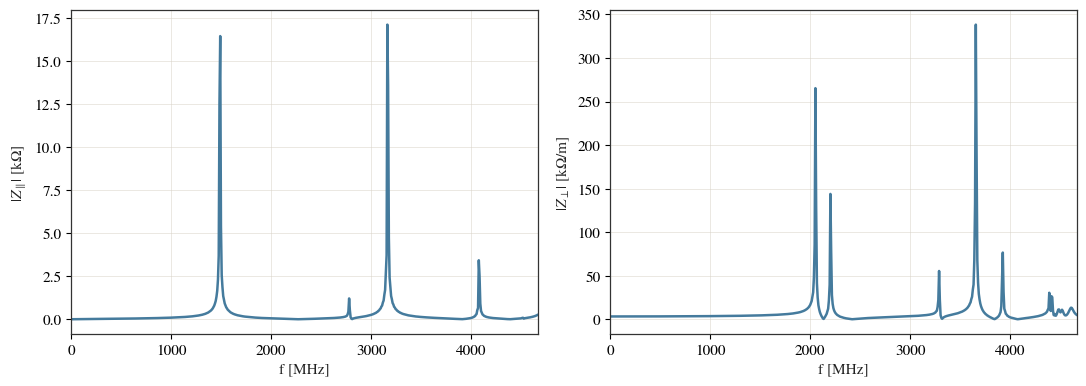

In [6]:
study.run_wakefield({'MROT': 2, 'wakelength': 5, 'bunch_length': 25})
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
cav.wakefield.plot_impedance(kind='longitudinal', ax=a0, show=False)
cav.wakefield.plot_impedance(kind='transverse', ax=a1, show=False)
plt.tight_layout()
plt.show()

That is the whole story: one small model class, and eigenmode, tuning and wakefield all work
— exactly as they do for the built-in cavities. See [A curved custom cavity](dome_cavity.ipynb)
for a model with an arc wall and a multipacting run, and the
[writing a new cavity model](../../extending) guide for the full contract.